# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 1/4

**NOMBRES:**
1. María Paula Rodríguez Muñoz
2. Andres Felipe Cardozo Martinez 

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*

---
**Derivada función Sigmoide:**

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Ahora vamos a derivar la función Sigmoide:

$$
\frac{d}{dz}\sigma(z)
$$

Reescribimos la función para mayor simplicidad:

$$
\sigma(z) = (1 + e^{-z})^{-1}
$$

Y aplicamos la regla de la cadena:

$$
\frac{d}{dz}\sigma(z) = -1(1 + e^{-z})^{-2} \cdot \frac{d}{dz}(1 + e^{-z})
$$

Como ya sabemos que:

$$
\frac{d}{dz}(1 + e^{-z}) = -e^{-z}
$$

Entonces:

$$
\frac{d}{dz}\sigma(z) = -(1 + e^{-z})^{-2}(-e^{-z})
$$

$$
\frac{d}{dz}\sigma(z) = \frac{e^{-z}}{(1 + e^{-z})^2}
$$

Ahora expresamos el resultado en términos de $\sigma(z)$:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

y

$$
1 - \sigma(z) = 1 - \frac{1}{1 + e^{-z}} = \frac{e^{-z}}{1 + e^{-z}}
$$

Multiplicando:

$$
\sigma(z)(1 - \sigma(z)) = \frac{1}{1 + e^{-z}} \cdot \frac{e^{-z}}{1 + e^{-z}} = \frac{e^{-z}}{(1 + e^{-z})^2}
$$

Por último esta es la derivada:

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z))
$$

---
**Derivada función ReLU**

$$
\text{ReLU}(z) = \max(0, z)
$$

La función ReLU  se define de la siguiente manera:

$$
\text{ReLU}(z) =
\begin{cases}
0, & z \leq 0 \\
z, & z > 0
\end{cases}
$$

Derivando por tramos:

Si $z < 0$, la función es constante igual a 0, entonces:

$$
\frac{d}{dz}\text{ReLU}(z) = 0
$$

Si $z > 0$, la función es $z$, entonces:

$$
\frac{d}{dz}\text{ReLU}(z) = 1
$$

Por lo tanto la derivada de ReLU es:

$$
\text{ReLU}'(z) =
\begin{cases}
0, & z < 0 \\
1, & z > 0
\end{cases}
$$

---
**Derivada función de costo: Entropia Cruzada**

La entropía cruzada general es:

$$
H(p,q) = -\sum_{x \in clases} p(x)\log q(x)
$$

Cuando se usa sigmoide (clasificación binaria):

$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m}
\left[
y^{(i)} \log(z^{(i)}) + (1 - y^{(i)}) \log(1 - z^{(i)})
\right]
$$

donde:

- $z = \sigma(a)$  
- $a = w^T x$  

### Derivada respecto a $z$ usando la regla de la cadena

$$
\frac{\partial J}{\partial z} =
\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z}
$$

Entonces:

$$
\frac{\partial J}{\partial z} =
-\left(\frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}}\right)
$$


Simplificando:

$$
\frac{\partial J}{\partial z} 
=
\frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}
$$



## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [1]:
import numpy as np
import pandas as pd
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

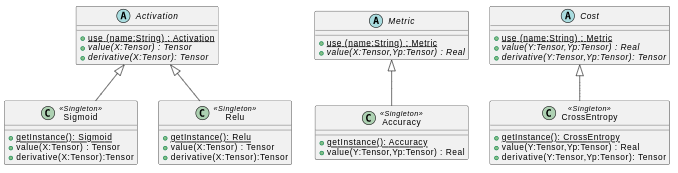

### MÉTRICA

In [2]:
class Metric(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica
  Representa la metrica de una red neuronal
  """
  def use(self, name: str) -> "Metric":
    """ obtiene metrica (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la metrica
    Returns:
      self (Metric): objeto metrica
    """

    name = name.lower()

    if name == "accuracy":
      return Accuracy.getInstance()
    raise ValueError("Metrica no encontrada.")

  
  @abstractmethod
  def value(self, Y: np.ndarray, Yp:np.ndarray) -> float:
    """ computa el desempeño (accuracy) de la red (> 0.6 es 1)
    Args:
      Y (ndarray): valores de salidas esperadas (etiquetadas)
      Yp (ndarray): valores de salidas obtenidas
    Return:
      A (float): valor del desempeño
    """
    pass

Proporción total de predicciones correctas sobre el total de casos.

$$
    Accuracy = \frac{TP + TN}{Total}
$$

In [3]:
# Documentar los métodos implementados
class Accuracy(Metric):
  """ Metrica de exactitud (acertados / totales). Implementa Metric
  """
  _instance = None
  
  def Acurracy(self):
    return self.getInstance()

  @staticmethod
  def getInstance():
    """ Obtiene la isntancia
    """
    if Accuracy._instance is None:
      Accuracy._instance = Accuracy()
    return Accuracy._instance
  
  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa el desempeño (accuracy) de la red (> 0.6 es 1)
    Args:
      Y (ndarray): valores de salidas esperadas (etiquetadas)
      Yp (ndarray): valores de salidas obtenidas
    Return:
      A (float): valor del desempeño
    """
    Y = np.asarray(Y)
    Yp = np.asarray(Yp)

    if Y.shape != Yp.shape:
      raise ValueError("Y y Yp deben tener la misma forma")

    Yp_bin = (Yp > 0.6).astype(int)
    total = Y.size
    correctos = np.sum(Y == Yp_bin)

    return float(correctos / total)

In [4]:
# Adicione los casos de prueba de los métodos implementados

Y = pd.DataFrame([1, 0, 1, 1, 0]) 
Yp = pd.DataFrame([1, 0, 1, 0, 1])

accuracy = Accuracy().value(Y, Yp)

print(f"Accuracy:" , accuracy)

Accuracy: 0.6


In [5]:
Y = pd.DataFrame([1, 0, 1, 1, 1]) 
Yp = pd.DataFrame([1, 0, 1, 1, 1])

accuracy = Accuracy().value(Y, Yp)
print(f"Accuracy:" , accuracy)

Accuracy: 1.0


In [6]:
Y = [1, 0, 1, 1, 1]
Yp = [1, 0, 1, 1, 1]

accuracy = Accuracy().value(Y, Yp)
print(f"Accuracy:" , accuracy)


Y = [1, 0, 1, 1, 1]
Yp = [0.8, 0.1, 1, 1, 1]

accuracy = Accuracy().value(Y, Yp)
print(f"Accuracy:" , accuracy)

Accuracy: 1.0
Accuracy: 1.0


### COSTO

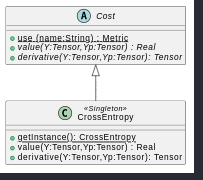

**Fórmulas usadas en Cross Entropy (binaria):**

Pérdida promedio:
$$
J = -\frac{1}{m}\sum_{i=1}^{m}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

Derivada respecto a la predicción 
$
(\hat{y})
$
:
$$
\frac{\partial J}{\partial \hat{y}} = \frac{\hat{y}-y}{\hat{y}(1-\hat{y})}
$$

Estabilización numérica (para evitar $ (\log(0))  $ y división por cero):
$$
\hat{y} \leftarrow \mathrm{clip}(\hat{y},\epsilon,1-\epsilon),\quad \epsilon=10^{-12}
$$

In [7]:
class Cost(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo
  Representa la función de costo o error de una red neuronal
  """
  def use(self, name: str) -> "Cost":
    """ obtiene función de costo (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Cost): objeto función de costo
    """
    name = name.lower()
    if name in ["crossentropy", "cross_entropy"]:
      return CrossEntropy.getInstance()
    
    raise ValueError(f"Función de costo '{name}' no soportada")


  @abstractmethod
  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa la función de costo
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      S (float): valor de computo de la función de costo
    """
    pass
  @abstractmethod
  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de costo (gradiente) <elemento por elemento>
    Args:
      Y (ndarray): valores de salida obtenidos
      Yp (ndarray): valores de salida esperados
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de costo
    """
    pass

In [8]:
# Documentar los métodos implementados
class CrossEntropy(Cost):
  """ Función de costo Entropia Cruzada. Implementa Cost
  """
  _instance = None

  def CrossEntropy(self):
    return self.getInstance()

  @staticmethod
  def getInstance() -> "CrossEntropy":
    if CrossEntropy._instance is None:
      CrossEntropy._instance = CrossEntropy()
    return CrossEntropy._instance

  def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
    """ computa la función de costo
    Args:
      Y (ndarray): valores de salida esperados (etiquetas)
      Yp (ndarray): valores de salida obtenidos (predicciones)
    Returns:
      S (float): valor de computo de la función de costo
    """
    Y = np.asarray(Y)
    Yp = np.asarray(Yp)

    if Y.shape != Yp.shape:
      raise ValueError("Y y Yp deben tener la misma forma")

    eps = 1e-12
    Yp = np.clip(Yp, eps, 1 - eps)
    return float(-np.mean(Y * np.log(Yp) + (1 - Y) * np.log(1 - Yp)))

  def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
    Y = np.asarray(Y)
    Yp = np.asarray(Yp)

    if Y.shape != Yp.shape:
      raise ValueError("Y y Yp deben tener la misma forma")

    eps = 1e-12
    Yp = np.clip(Yp, eps, 1 - eps)
    return (Yp - Y) / (Yp * (1 - Yp))

In [9]:
# Adicione los casos de prueba de los métodos implementados
Y = [1, 0, 1, 1, 0]
Yp = [0.9, 0.1, 0.8, 0.4, 0.2]

ce = CrossEntropy().getInstance()
loss = ce.value(Y, Yp)
grad = ce.derivative(Y, Yp)

print("CrossEntropy:", loss)
print("Derivative:", grad)

CrossEntropy: 0.3146597731636454
Derivative: [-1.11111111  1.11111111 -1.25       -2.5         1.25      ]


In [10]:
Y = [1, 0, 1, 0, 0]
Yp = [0.7, 0.4, 0.8, 0.4, 0.2]

ce = CrossEntropy().getInstance()
loss = ce.value(Y, Yp)
grad = ce.derivative(Y, Yp)

print("CrossEntropy:", loss)
print("Derivative:", grad)

CrossEntropy: 0.36492265881982666
Derivative: [-1.42857143  1.66666667 -1.25        1.66666667  1.25      ]


### ACTIVACION

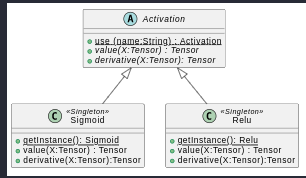

In [11]:
class Activation(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave de cualquier función de activación
  Representa la función de activación de cualquier neurona en la red neuronal
  """
  def use(self, name: str) -> "Activation":
    """ obtiene función de activación (OBJ) a partir del nombre
    Args:
      name (str): nombre esperado de la función
    Returns:
      self (Activation): objeto función de activación
    """
    name = name.lower()
    if name == "sigmoid":
      return Sigmoid.getInstance()
    if name == "relu":
      return Relu.getInstance()
    
    raise ValueError(f"Función de activación '{name}' no soportada")

  @abstractmethod
  def value(self, X: np.ndarray) -> np.ndarray:
    """ computa la función de activación <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      S (ndarray): valores de computo de la función de activación
    """
    pass
  
  @abstractmethod
  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de activación (gradiente) <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de activación
    """
    pass

In [12]:
# Documentar los métodos implementados
class Sigmoid(Activation):
  """ Función de activación sigmoide. Implementa Activación
  """
  _instance = None

  def Sigmoid(self):
    pass
  
  def getInstance():
    if Sigmoid._instance is None:
      Sigmoid._instance = Sigmoid()
    return Sigmoid._instance
  

  def value(self, X: np.ndarray) -> np.ndarray:
    """ computa la función de activación <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      S (ndarray): valores de computo de la función de activación
    """
    X = np.asarray(X)
    return 1 / (1 + np.exp(-X))

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de activación (gradiente) <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de activación
    """
    s = self.value(X)
    return s * (1 - s)

In [13]:
# Documentar los métodos implementados
class Relu(Activation):
  """ Función de activación RELU. Implementa Activación
  """
  _instance = None
  def Relu(self):
    pass
  
  def getInstance():
    if Relu._instance is None:
      Relu._instance = Relu()
    return Relu._instance
  

  def value(self, X: np.ndarray) -> np.ndarray:
    """ computa la función de activación <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      S (ndarray): valores de computo de la función de activación
    """
    X = np.asarray(X)
    return np.maximum(0, X)

  def derivative(self, X: np.ndarray) -> np.ndarray:
    """ computa la derivada de la función de activación (gradiente) <elemento por elemento>
    Args:
      X (ndarray): valores de entrada
    Returns:
      ∇E(X) (ndarray): valores para la derivada de función de activación
    """
    X = np.asarray(X)
    return (X > 0).astype(X.dtype)

In [14]:
# Adicione los casos de prueba de los métodos implementados
X = np.array([-2.0, 0.0, 2.0])

sigmoid = Sigmoid.getInstance()
relu = Relu.getInstance()

print("Sigmoid value:", sigmoid.value(X))
print("Sigmoid derivative:", sigmoid.derivative(X))

print("Relu value:", relu.value(X))
print("Relu derivative:", relu.derivative(X))

# Comprobaciones rápidas
assert np.allclose(relu.value(X), np.array([0.0, 0.0, 2.0]))
assert np.allclose(relu.derivative(X), np.array([0.0, 0.0, 1.0]))
print("Pruebas basicas de activacion OK")

Sigmoid value: [0.11920292 0.5        0.88079708]
Sigmoid derivative: [0.10499359 0.25       0.10499359]
Relu value: [0. 0. 2.]
Relu derivative: [0. 0. 1.]
Pruebas basicas de activacion OK


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

#### Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

---
**Gradiente dW**



Sabemos que:

$$
Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}
$$

Queremos:

$$
dW^{[l]} = \frac{\partial L}{\partial W^{[l]}}
$$

Aplicamos regla de la cadena:

$$
\frac{\partial L}{\partial W^{[l]}} =
\frac{\partial L}{\partial Z^{[l]}} \cdot
\frac{\partial Z^{[l]}}{\partial W^{[l]}}
$$

Sabemos que:

$$
\frac{\partial Z^{[l]}}{\partial W^{[l]}} = A^{[l-1]}
$$

Por tanto:

$$
dW^{[l]} = dZ^{[l]} \cdot (A^{[l-1]})^T
$$

Como estamos trabajando con múltiples ejemplos ($m$), promediamos:

$$
\boxed{
dW^{[l]} = \frac{1}{m} dZ^{[l]} (A^{[l-1]})^T
}
$$


---
**Graciente db**

Partimos nuevamente de:

$$
Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}
$$

Queremos:

$$
db^{[l]} = \frac{\partial L}{\partial b^{[l]}}
$$

Aplicando regla de la cadena:

$$
\frac{\partial L}{\partial b^{[l]}} =
\frac{\partial L}{\partial Z^{[l]}} \cdot
\frac{\partial Z^{[l]}}{\partial b^{[l]}}
$$

Como:

$$
\frac{\partial Z^{[l]}}{\partial b^{[l]}} = 1
$$

Entonces:

$$
db^{[l]} = dZ^{[l]}
$$

Para múltiples ejemplos:

$$
\boxed{
db^{[l]} = \frac{1}{m} \sum dZ^{[l]}
}
$$


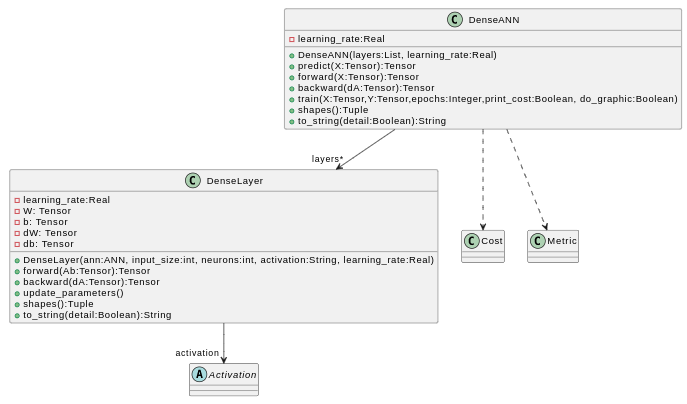

In [16]:
import matplotlib.pyplot as plt

In [17]:
class DenseANN:
  """ Representa una red neuronal totalmente conectada
  """
  def __init__(self, layers: list, learning_rate: float):
    """ inicializar las capas, luego almacenar la arquitectura de la red y la tasa de aprendizaje.
    Args:
      layers (list): número de -> caracteristicas de entrada (list[0]), neuronas en la capa oculta i, neuronas de salida (list[-1])
      learning_rate (float): es la tasa de aprendizaje de la red
    """
    self.learning_rate = learning_rate
    self.layers = [] 

    for i in range(1, len(layers)):
            input_size = layers[i-1]
            neurons = layers[i]

            activation_str = 'relu' if i < len(layers) - 1 else 'sigmoid'

            layer = DenseLayer(input_size, neurons, activation_str, learning_rate)
            self.layers.append(layer)


  def predict(self, X: np.ndarray):
    """ computa valores de predicción a partir de las entradas
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    Yp = self.forward(X)
    return Yp

  def forward(self, X: np.ndarray):
    """ computa hacia adelante un ciclo de entradas a traves de la red generando una predicción
    Args:
      X (ndarray): valores de características (entradas)
    Return:
      Yp (ndarray): valores de salidas obtenidas
    """
    A = X

    for layer in self.layers:
        A = layer.forward(A)
    return A

  def backward(self, dA: np.ndarray):
    """ computa hacia atras los errores y gradientes
    Args:
      dA (ndarray): valores del gradiente de predicción
    Return:
      G (ndarray): gradientes de la red
    """
    dZ = dA
    for layer in reversed(self.layers):
        dZ = layer.backward(dZ)
        layer.update_parameters()
    return dZ

  def train(self, X: np.ndarray, Y: np.ndarray, epochs: int, print_cost: bool, do_graphic: bool):
    """ entrenar red neuronal
    Args:
      X (ndarray): valores de características - conjunto de entrenamiento
      Y (ndarray): valores de salidas esperadas - conjunto de entrenamiento
      epochs (int): número de iteraciones
      print_cost (bool): mostrar el costo por iteración
      do_graphic (bool): graficar el costo por iteración
    """
    costs = []
    cost_func = CrossEntropy.getInstance()
    metric = Accuracy.getInstance()
    
    for i in range(epochs):
        Yp = self.forward(X)

        cost = cost_func.value(Y, Yp) 
        costs.append(cost)    

        acc = metric.value(Y, Yp)

        dA = cost_func.derivative(Y, Yp)
        self.backward(dA)

        if print_cost and (i % 100 == 0 or i == epochs - 1):
            print(f"Iteración {i} -> Costo: {cost:.6f}, Accuracy: {acc:.4f}")
            
    if do_graphic:
        import matplotlib.pyplot as plt
        plt.plot(np.squeeze(costs))
        plt.ylabel('Costo (CrossEntropy)')
        plt.xlabel('Iteraciones')
        plt.title(f"Tasa de aprendizaje = {self.learning_rate}")
        plt.show()

  def shapes():
    """ genera los valores asociados al tamaño de la red
    Return:
      s (tupla<int>): tamaño de la red
    """
    return tuple([layer.shapes() for layer in self.layers])

  def to_string():
    """
    """
    s = f"DenseANN con learning_rate={self.learning_rate}:\n"
    for i, layer in enumerate(self.layers):
        s += f"  Capa {i+1}: {layer.to_string(detail)}\n"
    return s

## CAPA CON PERCEPTRONES

In [18]:
class DenseLayer:
  """ Representa una capa (oculta o salida) en la red neuronal
  """
  def __init__(self, input_size: int, neurons: int, activation: str, learning_rate: float):
    """ inicializar una capa de neuronas dentro de la red neuronal.
    Args:
      input_size (int): número de neuronas de capa anterior o de atributos de entrada
      neurons (int): número de neuronas en la capa
      activation (str): nombre de la función de activación
      learning_rate (float): eta tasa de aprendizaje de la red
    """
    self.learning_rate = learning_rate
    self.W = np.random.randn(neurons, input_size) * 0.5
    self.b = np.zeros((neurons, 1))
    self.dW = np.zeros_like(self.W)
    self.db = np.zeros_like(self.b)
    self.activation_func = Activation.use(self, activation)
    self.A_prev = None
    self.Z = None

  def forward(self, Ab: np.ndarray):
    """ Transmite la entrada a partir del acumulativo de señales (f_base) y el potencial eléctrico (f_activación).
    Args:
      Ab (np.ndarray): características ó valores de activación de la capa anterior
    Return:
      S (np.ndarray): valores de activación de neuronas
    """
    self.A_prev = Ab
    self.Z = np.dot(self.W, self.A_prev) + self.b
    S = self.activation_func.value(self.Z)
    return S

  def backward(self, Ab: np.ndarray):
    """ Transmite hacia atras el cambio del grandiente y el error (delta)
    Args:
      Ab (np.ndarray): características ó valores de error de la capa siguiente
      [capa salida] valores etiquetados esperados | [capa oculta] delta capa siguiente
    Return:
      S (np.ndarray): valor delta considerando gradiente y error
    """
    m = self.A_prev.shape[1]
    dZ = Ab * self.activation_func.derivative(self.Z)
    
    self.dW = (1 / m) * np.dot(dZ, self.A_prev.T)
    self.db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    
    S = np.dot(self.W.T, dZ)
    return S

  def update_parameters(self):
    """ Actualiza los parámetros de la capa a partir del gradiente y el error.
    Return:
    """
    self.W -= self.learning_rate * self.dW
    self.b -= self.learning_rate * self.db

  def shapes(self):
    """ genera los valores asociados al tamaño de la capa
    Return:
      s (tupla<int>): tamaño de la capa
    """
    return (self.W.shape, self.b.shape)

  def to_string(self, detail: bool):
    """
    """
    info = f"W: {self.W.shape}, b: {self.b.shape}"
    if detail:
        info += f"\n  dW: {self.dW.shape if self.dW is not None else None}, db: {self.db.shape if self.db is not None else None}"
    return info

# AND

Iteración 0 -> Costo: 0.700780, Accuracy: 0.7500
Iteración 100 -> Costo: 0.450090, Accuracy: 0.7500
Iteración 200 -> Costo: 0.355780, Accuracy: 0.7500
Iteración 300 -> Costo: 0.296790, Accuracy: 1.0000
Iteración 400 -> Costo: 0.255871, Accuracy: 1.0000
Iteración 500 -> Costo: 0.225454, Accuracy: 1.0000
Iteración 600 -> Costo: 0.201755, Accuracy: 1.0000
Iteración 700 -> Costo: 0.182664, Accuracy: 1.0000
Iteración 800 -> Costo: 0.166900, Accuracy: 1.0000
Iteración 900 -> Costo: 0.153635, Accuracy: 1.0000
Iteración 999 -> Costo: 0.142408, Accuracy: 1.0000


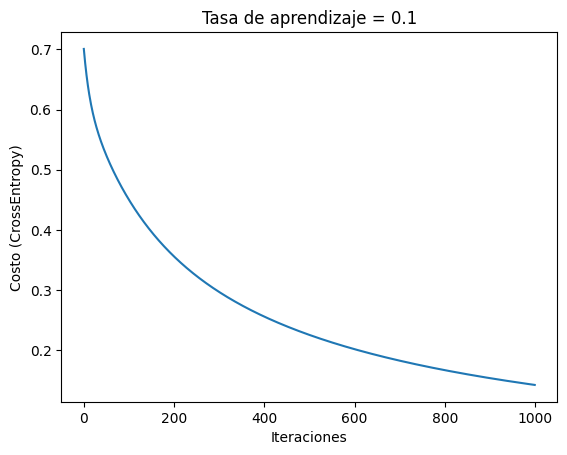

[[0.00817496 0.14843601 0.14918337 0.78760177]]


In [19]:
# Como primer caso de prueba entrene un perceptrón para calcular el operador lógico and. Explique los resultados.

X = np.array([[0, 0, 1, 1],[0, 1, 0, 1]])

Y = np.array([[0, 0, 0, 1]])

ann = DenseANN(layers=[2, 1], learning_rate=0.1)

ann.train(X, Y, epochs=1000, print_cost=True, do_graphic=True)

predicciones = ann.predict(X)

print(predicciones)

### Explicación
En este caso de prueba, tenemos un perceptrón con dos entradas y una salida. 

Solo hay un caso donde la salida es 1, que es (1,1).

Al comienzo, se observa que el modelo presenta un costo alto y una accuracy parcial, ya que no ha aprendido la relación entre las entradas y la salida. Pero, a medida que avanza el entrenamiento, el costo disminuye, lo que indica que esta mejorando sus predicciones.

A partir de cierta iteración, por ejemplo desde la 100 se observa que ya clasifica correctamente todos los ejemplos. Esto pasa ya que es posible dividir las clases mediante una linea, es decir, son linealmente separables. 

# OR

Iteración 0 -> Costo: 1.203723, Accuracy: 0.2500
Iteración 100 -> Costo: 0.410347, Accuracy: 0.7500
Iteración 200 -> Costo: 0.309188, Accuracy: 1.0000
Iteración 300 -> Costo: 0.245563, Accuracy: 1.0000
Iteración 400 -> Costo: 0.202459, Accuracy: 1.0000
Iteración 500 -> Costo: 0.171569, Accuracy: 1.0000
Iteración 600 -> Costo: 0.148434, Accuracy: 1.0000
Iteración 700 -> Costo: 0.130509, Accuracy: 1.0000
Iteración 800 -> Costo: 0.116245, Accuracy: 1.0000
Iteración 900 -> Costo: 0.104649, Accuracy: 1.0000
Iteración 999 -> Costo: 0.095140, Accuracy: 1.0000


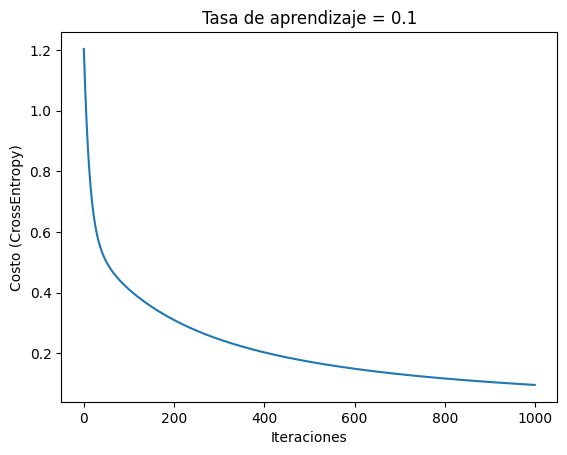

[[0.19728291 0.92526507 0.92209704 0.9983257 ]]


In [20]:
# Como segundo caso de prueba entrene un perceptrón para calcular el operador lógico or. Explique los resultados.

X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])

Y = np.array([[0, 1, 1, 1]])

ann = DenseANN(layers=[2, 1], learning_rate=0.1)

ann.train(X, Y, epochs=1000, print_cost=True, do_graphic=True)

predicciones = ann.predict(X)

print(predicciones)


### Explicación
En este caso de prueba, tenemos un perceptrón con dos entradas y una salida. 

Similar al anterior (AND), pero ahora es más sencillo ya que hay 3 casos donde la salida es 1, que son (0,0), (0,1), (1,0) y solo una donde es 0.

Al comienzo, se observa que el modelo presenta un costo alto y una accuracy parcial, ya que no ha aprendido la relación entre las entradas y la salida. Pero, a medida que avanza el entrenamiento, el costo disminuye mucho más rápido y la accuracy aumenta, alcanzando su valor máximo en pocas iteraciones, ya que de cierta forma el patrón es más "sencillo"

Esto porque es posible dividir las clases mediante una linea, es decir, son linealmente separables. 

# XOR

Iteración 0 -> Costo: 0.759847, Accuracy: 0.5000
Iteración 100 -> Costo: 0.705161, Accuracy: 0.7500
Iteración 200 -> Costo: 0.696958, Accuracy: 0.5000
Iteración 300 -> Costo: 0.694395, Accuracy: 0.5000
Iteración 400 -> Costo: 0.693575, Accuracy: 0.5000
Iteración 500 -> Costo: 0.693302, Accuracy: 0.5000
Iteración 600 -> Costo: 0.693206, Accuracy: 0.5000
Iteración 700 -> Costo: 0.693171, Accuracy: 0.5000
Iteración 800 -> Costo: 0.693157, Accuracy: 0.5000
Iteración 900 -> Costo: 0.693151, Accuracy: 0.5000
Iteración 999 -> Costo: 0.693149, Accuracy: 0.5000


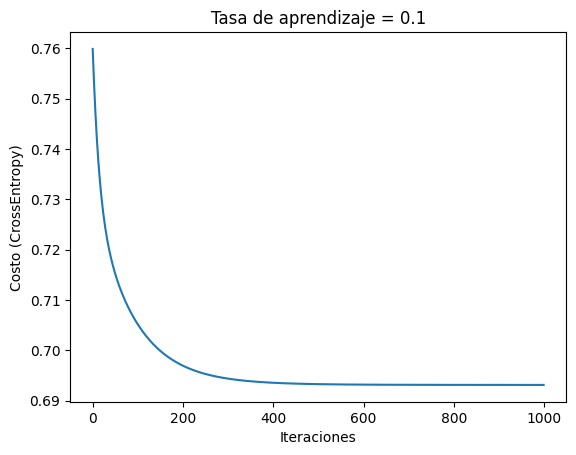

[[0.50149784 0.4998771  0.50059301 0.49897227]]


In [21]:
# Como tercer caso de prueba entrene un perceptrón para calcular el operador lógico xor. Explique los resultados.
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])

Y = np.array([[0, 1, 1, 0]])

ann = DenseANN(layers=[2, 1], learning_rate=0.1)

ann.train(X, Y, epochs=1000, print_cost=True, do_graphic=True)

predicciones = ann.predict(X)

print(predicciones)



### Explicación 
En este caso de prueba, igual se entrena un perceptrón con dos entradas y una salida para modelar el operador lógico XOR. 

A diferencia de los anteriores, el modelo no puede aprender correctamente la funcion, porque como se observa el costo se mantiene practicamente constante durante todas las iteraciones y la accuracy no mejora, permaneciendo en un valor de 0.5.

Esto pasa porque no es linealmente separable, es decir no podemos dividir las clases con una sola línea. Y como el perceptrón simple solo aprende realaciones lineales, no es capaz de modelar este problema.

Finalmente vemos que termina generando predicciones cercanas a un valor constante, sin diferencias bien entre las clases.

# XOR - Perceptrón Multicapa

Iteración 0 -> Costo: 0.693895, Accuracy: 0.5000
Iteración 100 -> Costo: 0.565284, Accuracy: 0.7500
Iteración 200 -> Costo: 0.453474, Accuracy: 0.7500
Iteración 300 -> Costo: 0.350396, Accuracy: 0.7500
Iteración 400 -> Costo: 0.249202, Accuracy: 0.7500
Iteración 500 -> Costo: 0.172697, Accuracy: 1.0000
Iteración 600 -> Costo: 0.122616, Accuracy: 1.0000
Iteración 700 -> Costo: 0.091575, Accuracy: 1.0000
Iteración 800 -> Costo: 0.070652, Accuracy: 1.0000
Iteración 900 -> Costo: 0.057054, Accuracy: 1.0000
Iteración 1000 -> Costo: 0.047007, Accuracy: 1.0000
Iteración 1100 -> Costo: 0.039956, Accuracy: 1.0000
Iteración 1200 -> Costo: 0.034417, Accuracy: 1.0000
Iteración 1300 -> Costo: 0.030166, Accuracy: 1.0000
Iteración 1400 -> Costo: 0.026667, Accuracy: 1.0000
Iteración 1500 -> Costo: 0.023883, Accuracy: 1.0000
Iteración 1600 -> Costo: 0.021641, Accuracy: 1.0000
Iteración 1700 -> Costo: 0.019691, Accuracy: 1.0000
Iteración 1800 -> Costo: 0.018064, Accuracy: 1.0000
Iteración 1900 -> Costo:

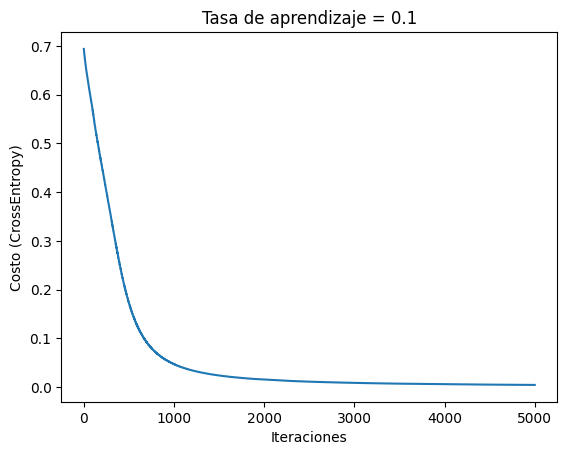

[[0.00242323 0.99872402 0.9874653  0.00183183]]


In [22]:
# Como cuarto caso de prueba entrene un perceptrón multicapa [2,2,1] para calcular el operador lógico xor. Explique los resultados

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])

Y = np.array([[0, 1, 1, 0]])

ann = DenseANN(layers=[2, 2, 1], learning_rate=0.1)

ann.train(X, Y, epochs=5000, print_cost=True, do_graphic=True)

predicciones = ann.predict(X)

print(predicciones)


### Explicación 

En este caso de prueba, se entrena una red neuronal multicapa con arquitectura [2,2,1] para modelar el operador lógico XOR, el cual no es linealmente separable.

A diferencia del perceptrón simple, esta red incluye una capa oculta, lo que le permite modelar relaciones no lineales. Por esta razón, el modelo logra mejorar su desempeño durante el entrenamiento, pasando de una accuracy inicial de 0.5 a 0.75.

Pero, se observa que después de cierto número de iteraciones, la accuracy se queda en un valor y no alcanza el valor máximo. Esto indica que, aunque la red ha aprendido de cierta forma el patrón, no logra clasificar correctamente todos los ejemplos.

Iteración 0 -> Costo: 0.712655, Accuracy: 0.1759
Iteración 100 -> Costo: 0.543346, Accuracy: 0.8275
Iteración 200 -> Costo: 0.473718, Accuracy: 0.8309
Iteración 300 -> Costo: 0.442411, Accuracy: 0.8367
Iteración 400 -> Costo: 0.417243, Accuracy: 0.8516
Iteración 500 -> Costo: 0.394490, Accuracy: 0.8612
Iteración 600 -> Costo: 0.373206, Accuracy: 0.8728
Iteración 700 -> Costo: 0.353082, Accuracy: 0.8823
Iteración 800 -> Costo: 0.334210, Accuracy: 0.8930
Iteración 900 -> Costo: 0.316489, Accuracy: 0.9025
Iteración 1000 -> Costo: 0.299845, Accuracy: 0.9092
Iteración 1100 -> Costo: 0.284255, Accuracy: 0.9145
Iteración 1200 -> Costo: 0.269585, Accuracy: 0.9205
Iteración 1300 -> Costo: 0.255770, Accuracy: 0.9259
Iteración 1400 -> Costo: 0.242746, Accuracy: 0.9319
Iteración 1500 -> Costo: 0.230534, Accuracy: 0.9367
Iteración 1600 -> Costo: 0.219158, Accuracy: 0.9406
Iteración 1700 -> Costo: 0.208599, Accuracy: 0.9437
Iteración 1800 -> Costo: 0.198804, Accuracy: 0.9473
Iteración 1900 -> Costo:

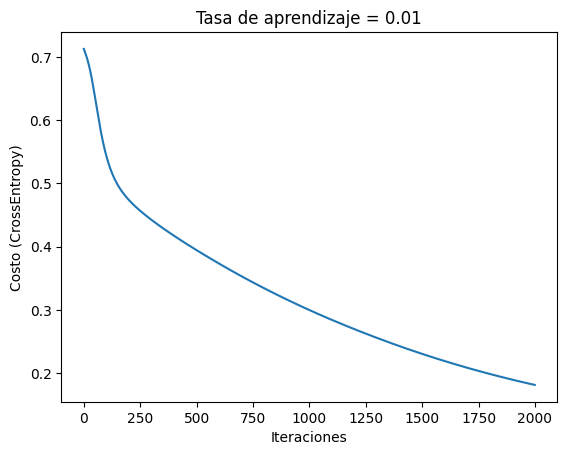

Accuracy entrenamiento: 0.9396875
Accuracy prueba: 0.93625


In [23]:
# Como último caso de prueba entrene una red para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.

import pandas as pd
import numpy as np

df = pd.read_csv("BEED_Data.csv")

X = df.iloc[:, :-1].values.T
Y = df.iloc[:, -1].values.reshape(1, -1)

# Limpiar datos
X = np.nan_to_num(X)

# Normalizar
X = X / np.max(X, axis=1, keepdims=True)

# Asegurar binario
Y = (Y > 0).astype(int)

perm = np.random.permutation(X.shape[1])
X = X[:, perm]
Y = Y[:, perm]

# Dividir 80/20
m = X.shape[1]
split = int(0.8 * m)

X_train = X[:, :split]
Y_train = Y[:, :split]

X_test = X[:, split:]
Y_test = Y[:, split:]

# Modelo
ann = DenseANN(layers=[X.shape[0], 16, 8, 1], learning_rate=0.01)

# Entrenamiento
ann.train(X_train, Y_train, epochs=2000, print_cost=True, do_graphic=True)

# Evaluación
pred_train = ann.predict(X_train)
pred_test = ann.predict(X_test)

pred_train_bin = (pred_train > 0.5).astype(int)
pred_test_bin = (pred_test > 0.5).astype(int)

train_acc = np.mean(pred_train_bin == Y_train)
test_acc = np.mean(pred_test_bin == Y_test)

print("Accuracy entrenamiento:", train_acc)
print("Accuracy prueba:", test_acc)


# Explicación

En este caso, se entrena una red neuronal multicapa con un conjunto de datos real de señales EEG.

Inicialmente se observa un desempeño bajo, ya que no ha aprendido aún los patrones de los datos; sin embargo, a medida que avanza el entrenamiento, el costo disminuye de manera notoria y la exactitud aumenta, es decir, que está aprendiendo de forma correcta.

Se utilizó una división del 80% de los datos para entrenamiento y el 20% para pruebas. De esta forma, se puede evaluar la capacidad que tiene el modelo de generalizar. Al final, se obtiene una exactitud cercana al 95% en ambos casos, tanto en entrenamiento como en prueba.

Esto indica que no solo aprende los datos de entrenamiento, sino que también es capaz de generalizar a datos nuevos, evitando el overfitting.

# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

## Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


### Problema

En este caso, se define un problema de clasificación binaria utilizando un conjunto de datos de señales EEG, con el objetivo de identificar si una señal corresponde o no a un evento epiléptico.

Cada instancia del dataset contiene múltiples características que representan mediciones de la actividad cerebral, mientras que la variable de salida indica la clase a la que pertenece cada ejemplo.

Para evaluar el desempeño del modelo, se utilizará la métrica de exactitud (accuracy), la cual mide la proporción de predicciones correctas sobre el total de ejemplos. Esta métrica es la adecuada ya que el problema consiste en clasificar correctamente cada instancia en una de dos clases.

Se establecerá como umbral de buen desempeño una exactitud igual o superior al 90%, lo que indicaría que el modelo es capaz de aprender patrones relevantes en los datos y generalizar datos nuevos.

## Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

Primeras filas:
    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  

Dimensiones del dataset:
(8000, 17)

Columnas:
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'y'],
      dtype='str')

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 

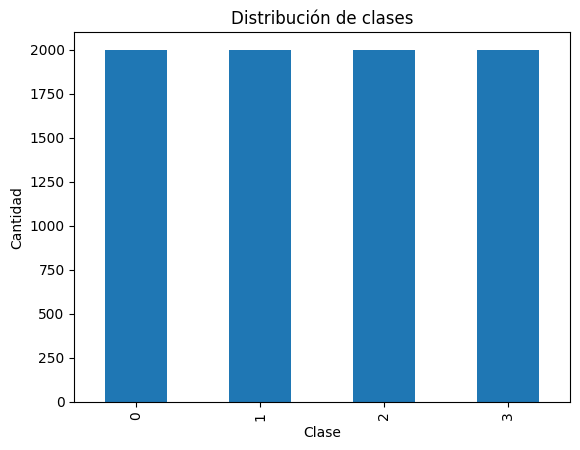

In [24]:
# Analizar los datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("BEED_Data.csv")

print("Primeras filas:")
print(df.head())

print("\nDimensiones del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

print("\nInformación general:")
print(df.info())

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
print(df.describe())

Y = df.iloc[:, -1]

print("\nDistribución de clases:")
print(Y.value_counts())

# Gráfica
Y.value_counts().plot(kind='bar')
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()



En primer lugar vemos que el conjunto de datos cuenta con 8000 registros y 17 columnas y que todas llas variables son de tipo numérico.

Al ver si hay valores nulos, vemos que no hay ningun dato faltante en ninguna columna, lo cual es bueno ya que no requiere hacerle nada por ese lado.

En las estadísticas vemos valores tanto positivos como negativos, con medias cercanas a cero en casi todos los casos. Se podria decir que estan relativamente centrados aunque hay una alta dispersión, pero es normal en este tipo de señales como EEG.

De la variable objetivo, se identifican 4 clases (0,1,2,3), cada una con 2000 registros, lo cual es balanceado y favorable para el entrenamiento.

In [25]:
#Preparar los datos separandolos en entrenamiento, validación y pruebas.

import pandas as pd
import tensorflow as tf
import numpy as np

# Cargar datos
df = pd.read_csv("BEED_Data.csv")
X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(np.float32)

# Normalización 
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / std

# Dividir 
n = X.shape[0]
train_end = int(0.6 * n)
val_end = int(0.8 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Tamaños:")
print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)
print("Prueba:", X_test.shape)



Tamaños:
Entrenamiento: (4800, 16)
Validación: (1600, 16)
Prueba: (1600, 16)


## Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [30]:
# Inicializar modelo Sequencial()
# Añadir capas de la clase Dense: .add(Dense(...))

import keras
from keras import Sequential, layers
from keras import ops

model = Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))  # especificamos input
model.add(layers.Dense(32, activation='relu', name='capa_oculta1'))
model.add(layers.Dense(16, activation='relu', name='capa_oculta2'))
model.add(layers.Dense(1, activation='linear', name='capa_salida'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta1 (Dense)            │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta2 (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [31]:
#Compilar el modelo

model.compile(
    optimizer='adam',   # Optimizador para actualizar los pesos
    loss='mse',         # Función de pérdida (Mean Squared Error)
    metrics=['mae']     # Métrica para evaluar el desempeño
)

### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

In [32]:
#Entrenar el modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5304 - mae: 0.5378 - val_loss: 1.4175 - val_mae: 1.1091
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1764 - mae: 0.3258 - val_loss: 0.8746 - val_mae: 0.8261
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1250 - mae: 0.2839 - val_loss: 0.7768 - val_mae: 0.7563
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0964 - mae: 0.2485 - val_loss: 0.7198 - val_mae: 0.7102
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0796 - mae: 0.2235 - val_loss: 0.6426 - val_mae: 0.6476
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0682 - mae: 0.2051 - val_loss: 0.6571 - val_mae: 0.6497
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0597 - mae: 0.1877 - val_loss: 0.5695 - val_mae: 0.5728
Epoch 8/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0531 - mae: 0.1753 - val_loss: 0.5583 - val_mae: 0.5559
Epoch 9/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

In [33]:
#Evaluar el modelo

loss, mae = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7783 - mae: 1.6102
Test Loss: 2.7783, Test MAE: 1.6102


## Paso 4: Redactar conclusiones

## Conclusiones
- Durante las primeras épocas, tanto la pérdida como el mae disminuyeron muy rápido, lo que indica que la red estaba aprendiendo correctamente los patrones presentes en los datos.
- También observamos que la pérdida y el mae en el conjunto de validación eran mucho más altos, pero más adelante se estabilizaron después de varias épocas. Se podría decir que el modelo generaliza bien, aunque hay cierta diferencia entre entrenamiento y validación, lo cual podría ser un indicador de un pequeño overfitting.
- Cuando se evaluó el modelo con los datos de prueba, las métricas indican que la red es capaz de predecir valores muy cercanos a los reales, con un error medio relativamente bajo.
- Por otro lado, se pudo observar que la mayoría del aprendizaje ocurrió en las primeras 40–50 épocas aproximadamente; después, la disminución de la pérdida y del mae fue un poco más lenta, probablemente debido a la gran cantidad de épocas. Quizá se podrían reducir para optimizar tiempo sin afectar mucho el rendimiento.
- En general, el modelo Keras con las dos capas ocultas, la función de activación ReLU, el optimizador Adam y la pérdida MSE, fue acertado para estos datos, ya que aprendió los patrones principales y mostró una buena generalización.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Nombre)

- 9 horas/María Paula Rodríguez Muñoz

- 9 horas/Andres Felipe Cardozo

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

- Terminado en su totalidad, ya que gracias al trabajo en equipo, una buena distribución de tareas y una correcta comprensión de los conceptos, se logró terminar satisfactoriamente.

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

- Nuestro mayor logro fue implementar y entrenar exitosamente la red neuronal para predecir los datos, logrando una buena generalización y precisión. Esto se considera un logro porque implicó aplicar los conceptos de Keras, ajuste de parámetros y análisis de resultados, alcanzando un buen modelo que funciona correctamente.

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

- En este caso, no hubo un gran problema técnico realmente.

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

- Hicimos bien la planificación del trabajo y la distribución de tareas
- Nos comprometemos a seguir trabajando de la mejor manera posible y a analizar correctamente los resultados, entendiendo bien cada uno de los conceptos.

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

- TensorFlow/Keras Documentation. Disponible en: https://keras.io/guides/sequential_model/